In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

plt.style.use("default")

In [2]:
conn=sqlite3.connect("sales.db")

In [4]:
df=pd.read_csv(r"C:\Users\Acer\Desktop\data_science_project\Sales_data_analysis_with_Sql\data\sales_data.csv")
df.to_sql("sales",conn,if_exists="replace",index=False)

12

In [16]:
sales_table=pd.read_sql("Select*From sales",conn)
sales_table

,order_id,order_date,region,product,quantity,unit_price
0,1001,2023-01-05,North,Laptop,2,55000
1,1002,2023-01-08,South,Mobile,5,18000
2,1003,2023-01-15,East,Tablet,3,25000
3,1004,2023-02-02,West,Laptop,1,56000
4,1005,2023-02-10,North,Mobile,4,17500
5,1006,2023-02-18,South,Laptop,2,54000
6,1007,2023-03-01,East,Mobile,6,18500
7,1008,2023-03-12,West,Tablet,2,26000
8,1009,2023-03-20,North,Laptop,3,54500
9,1010,2023-04-05,South,Tablet,4,25500


In [5]:
conn

In [7]:
query_monthly="""
Select strftime('%Y-%m',order_date) AS month,
Sum(quantity*unit_price) As total_sales 
from sales
Group by month
order by month ;
"""
monthly_sales=pd.read_sql(query_monthly,conn)
monthly_sales

,month,total_sales
0,2023-01,275000
1,2023-02,234000
2,2023-03,326500
3,2023-04,292000


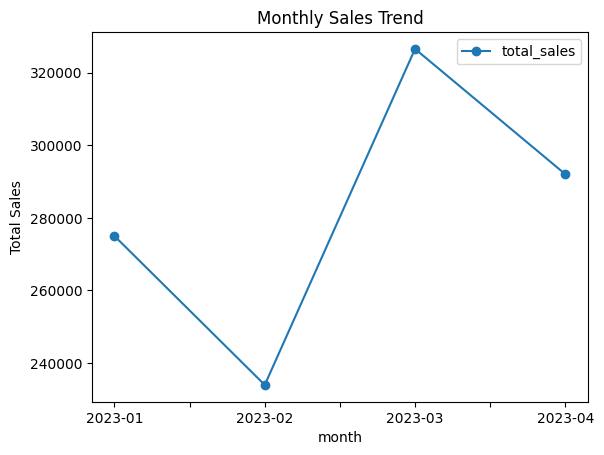

In [8]:
monthly_sales.plot(x='month',y='total_sales',kind='line',marker='o',title='Monthly Sales Trend')
plt.ylabel("Total Sales")
plt.show()

In [13]:
#Top Products by Revenue(sql)
query_products="""
Select product,Sum(quantity * unit_price) As total_revenue
From sales
Group by product 
Order by total_revenue Desc;
"""
product_sales=pd.read_sql(query_products,conn)
product_sales

,product,total_revenue
0,Laptop,494500
1,Mobile,404000
2,Tablet,229000


<function matplotlib.pyplot.show(close=None, block=None)>

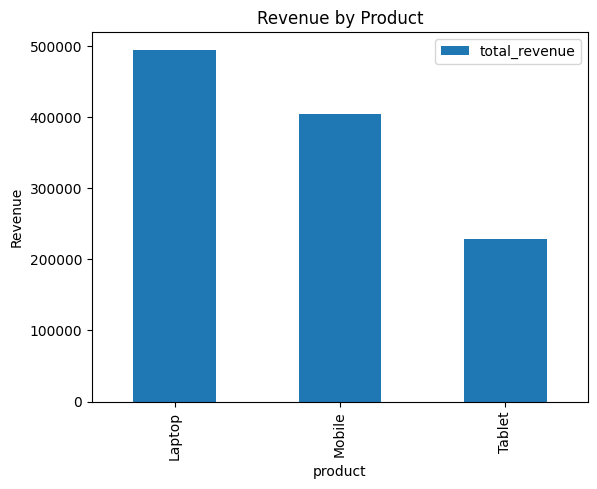

In [17]:
product_sales.plot(x='product',y='total_revenue',kind='bar',title='Revenue by Product')
plt.ylabel("Revenue")
plt.show

In [21]:
#Region-wise Sales Performance
query_region='''
Select region,Sum(quantity*unit_price) as regional_sales
From sales
Group by region
Order by regional_sales Desc ;
'''
region_sales=pd.read_sql(query_region,conn)
region_sales

,region,regional_sales
0,North,343500
1,South,300000
2,East,243000
3,West,241000


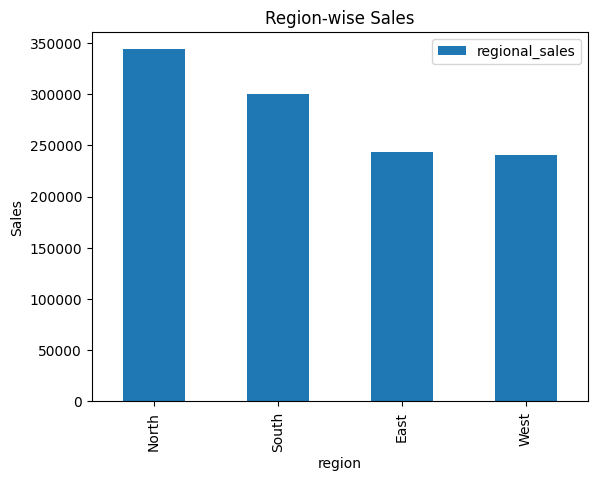

In [22]:
region_sales.plot(
    x='region',
    y='regional_sales',
    kind='bar',
    title='Region-wise Sales'
)
plt.ylabel("Sales")
plt.show()

In [23]:
#average order value(bonus)
query_aov='''
select avg(quantity * unit_price) As avg_order_value
from sales;
'''
aov=pd.read_sql(query_aov,conn)
aov

,avg_order_value
0,93958.333333


In [24]:
conn.close()

Built SQL queries and Python workflows to analyze sales data, identifying monthly revenue trends, top products, and region-wise performance.